In [2]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos 10 acciones de 5 sectores diferentes
tickers_sectores = {
    'AAPL': 'Tech', 'MSFT': 'Tech',
    'JPM': 'Finanzas', 'GS': 'Finanzas',
    'JNJ': 'Salud', 'PFE': 'Salud',
    'XOM': 'Energía', 'CVX': 'Energía',
    'WMT': 'Consumo', 'KO': 'Consumo'
}

tickers = list(tickers_sectores.keys())
data = yf.download(tickers, period='2y', auto_adjust=True)['Close']

print(f"Datos descargados: {data.shape[0]} días, {data.shape[1]} acciones")
data.head()

[*********************100%***********************]  10 of 10 completed

Datos descargados: 500 días, 10 acciones


Ticker,AAPL,CVX,GS,JNJ,JPM,KO,MSFT,PFE,WMT,XOM
Date,,,,,,,,,,
2024-05-28,188.358368,146.015076,440.754456,136.415771,191.258484,58.333725,423.661835,24.793766,63.845097,107.561218
2024-05-29,188.655746,144.050339,438.223877,136.472458,189.925903,58.220497,422.529663,24.373240,63.727295,106.409370
2024-05-30,189.647171,145.298935,434.183197,137.266098,191.095490,58.475269,408.253998,24.706158,63.697845,106.746498
2024-05-31,190.598953,149.008102,440.248993,138.579437,194.259171,59.381126,408.706879,25.109163,64.551857,109.808716
2024-06-03,192.363632,144.564484,438.763916,139.590424,193.482666,59.381126,407.121765,25.678635,64.610764,107.177269


In [3]:
# Retornos diarios
retornos = data.pct_change().dropna()

# Retorno acumulado total (en %)
retorno_total = ((data.iloc[-1] / data.iloc[0]) - 1) * 100

# Volatilidad anualizada (desviación estándar * raíz de 252 días hábiles)
volatilidad = retornos.std() * np.sqrt(252) * 100

# Sharpe ratio (asumimos tasa libre de riesgo del 4% anual)
tasa_libre_riesgo = 0.04
retorno_anual = retornos.mean() * 252
sharpe = (retorno_anual - tasa_libre_riesgo) / (retornos.std() * np.sqrt(252))

# Drawdown máximo (caída máxima desde un pico)
acumulado = (1 + retornos).cumprod()
pico = acumulado.cummax()
drawdown = ((acumulado - pico) / pico).min() * 100

# Armamos la tabla resumen
resumen = pd.DataFrame({
    'Sector': [tickers_sectores[t] for t in tickers],
    'Retorno Total %': retorno_total.values,
    'Volatilidad %': volatilidad.values,
    'Sharpe Ratio': sharpe.values,
    'Max Drawdown %': drawdown.values
}, index=tickers)

resumen = resumen.round(2).sort_values('Sharpe Ratio', ascending=False)
print(resumen)

        Sector  Retorno Total %  Volatilidad %  Sharpe Ratio  Max Drawdown %
GS    Finanzas            68.73          17.75          1.35          -14.45
JPM   Finanzas           125.64          30.97          1.35          -30.90
WMT    Consumo            85.72          23.75          1.27          -21.93
JNJ      Salud            60.38          25.10          0.92          -24.42
AAPL      Tech            63.69          28.19          0.88          -33.36
PFE      Salud            37.93          16.40          0.83          -15.50
KO     Consumo            39.28          24.16          0.65          -18.92
MSFT      Tech            26.50          23.76          0.45          -20.64
CVX    Energía             4.26          24.05          0.04          -29.00
XOM    Energía            -1.80          24.79         -0.07          -33.91


In [4]:
# Agrupamos por sector
por_sector = resumen.groupby('Sector').agg({
    'Retorno Total %': 'mean',
    'Volatilidad %': 'mean',
    'Sharpe Ratio': 'mean',
    'Max Drawdown %': 'mean'
}).round(2).sort_values('Sharpe Ratio', ascending=False)

print("Ranking de sectores por Sharpe Ratio:")
print(por_sector)

Ranking de sectores por Sharpe Ratio:
          Retorno Total %  Volatilidad %  Sharpe Ratio  Max Drawdown %
Sector                                                                
Finanzas            97.18          24.36          1.35          -22.67
Consumo             62.50          23.96          0.96          -20.42
Salud               49.16          20.75          0.88          -19.96
Tech                45.10          25.98          0.66          -27.00
Energía              1.23          24.42         -0.02          -31.46


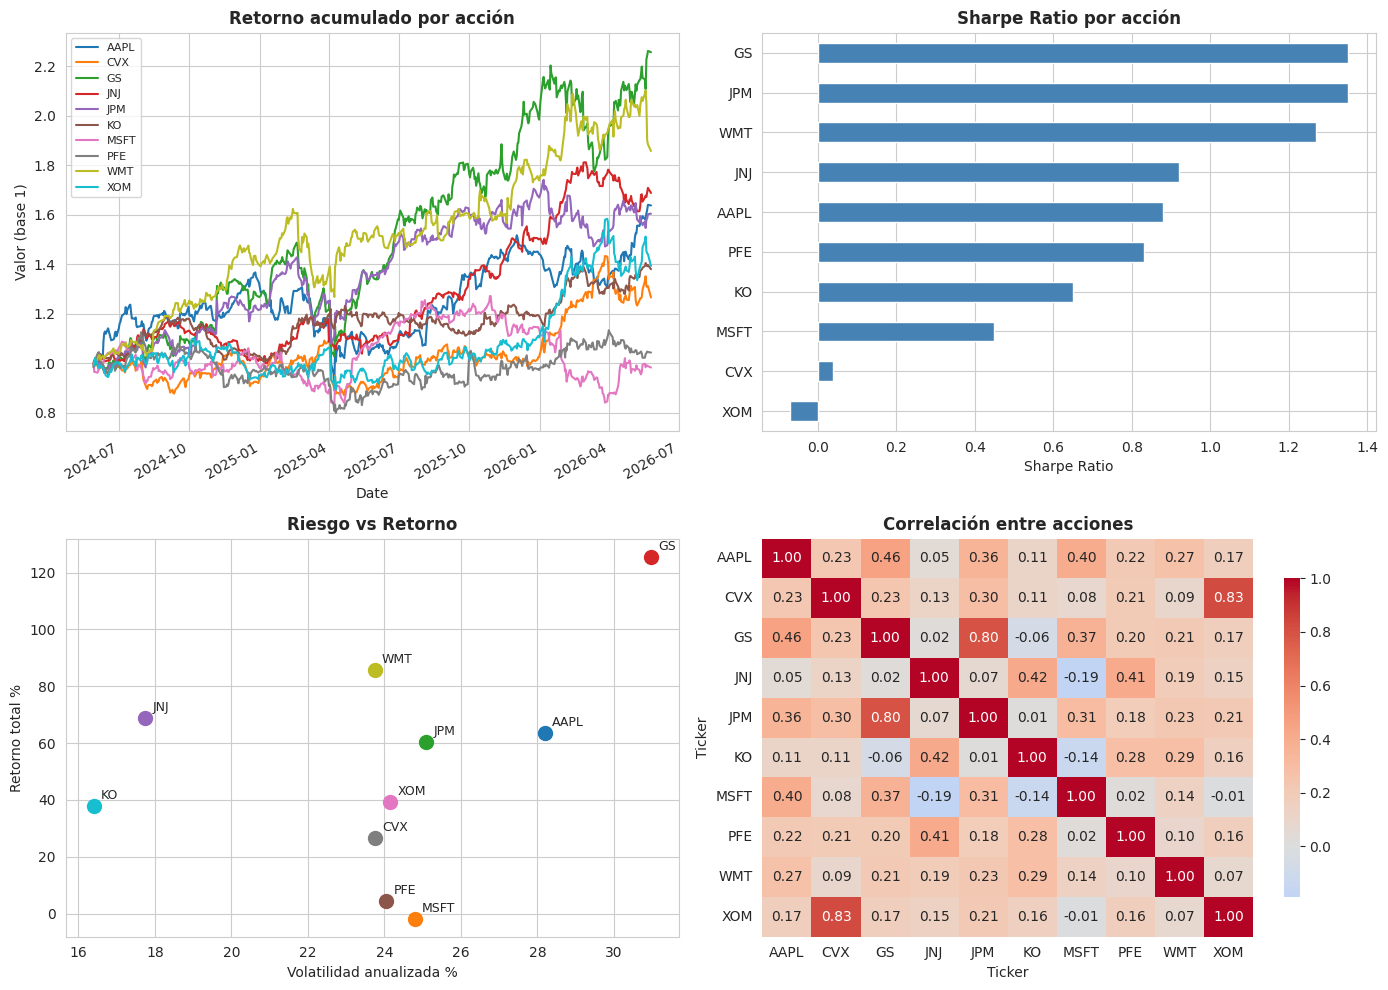

In [5]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Retorno acumulado
acumulado.plot(ax=axes[0,0], linewidth=1.5)
axes[0,0].set_title('Retorno acumulado por acción', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Valor (base 1)')
axes[0,0].legend(loc='upper left', fontsize=8)

# Gráfico 2: Sharpe por acción
resumen['Sharpe Ratio'].sort_values().plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Sharpe Ratio por acción', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Sharpe Ratio')

# Gráfico 3: Riesgo vs Retorno
for ticker in tickers:
    axes[1,0].scatter(volatilidad[ticker], retorno_total[ticker], s=100)
    axes[1,0].annotate(ticker, (volatilidad[ticker], retorno_total[ticker]),
                       xytext=(5,5), textcoords='offset points', fontsize=9)
axes[1,0].set_xlabel('Volatilidad anualizada %')
axes[1,0].set_ylabel('Retorno total %')
axes[1,0].set_title('Riesgo vs Retorno', fontsize=12, fontweight='bold')

# Gráfico 4: Correlación
sns.heatmap(retornos.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1,1], cbar_kws={'shrink': 0.8})
axes[1,1].set_title('Correlación entre acciones', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_sectores.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Guardamos los datos para usar en Excel o Power BI
resumen.to_csv('resumen_acciones.csv')
por_sector.to_csv('ranking_sectores.csv')
retornos.to_csv('retornos_diarios.csv')
acumulado.to_csv('retornos_acumulados.csv')

# Descargar archivos
from google.colab import files
files.download('resumen_acciones.csv')
files.download('ranking_sectores.csv')
files.download('retornos_diarios.csv')
files.download('retornos_acumulados.csv')

print("Archivos descargados. Listos para Excel o Power BI.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos descargados. Listos para Excel o Power BI.
